<a href="https://colab.research.google.com/github/usmantakai/ai-renewable-energy-projects/blob/main/Hybrid_microgrid_simulationl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

VERSION 1: Basic Hybrid Solar-Battery Model

soc_history length: 24
    Hour  Load (kW)  Solar (kW)  Battery soc (kWh)
0      0        1.2         0.0                1.3
1      1        1.0         0.0                0.3
2      2        0.9         0.0                0.0
3      3        0.8         0.0                0.0
4      4        0.7         0.0                0.0
5      5        0.6         0.0                0.0
6      6        1.0         0.5                0.0
7      7        2.0         1.5                0.0
8      8        2.5         2.5                0.0
9      9        3.0         3.0                0.0
10    10        3.2         3.2                0.0
11    11        3.0         3.0                0.0
12    12        2.8         2.8                0.0
13    13        2.5         2.5                0.0
14    14        2.2         2.0                0.0
15    15        2.0         1.5                0.0
16    16        1.8         1.0                0.0
17    17        1.6         0.5                0.0
18    18

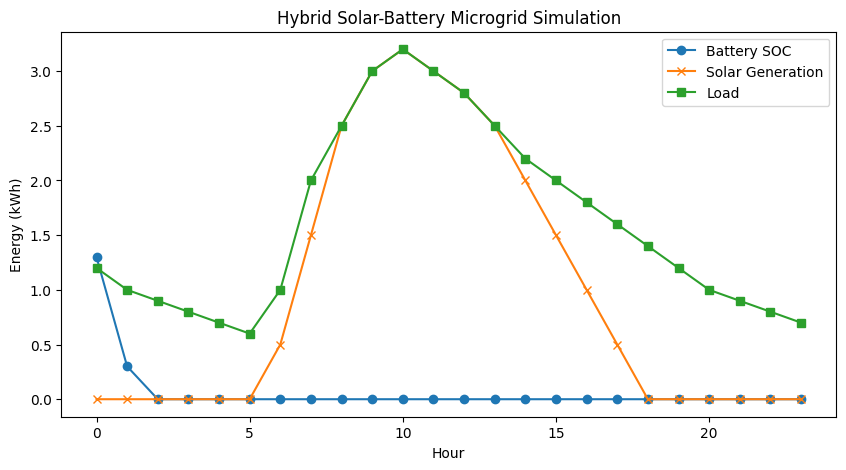

In [14]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. TIME SETUP
hours = np.arange(24) # 24 hours

# 2. LOAD & SOLAR PROFILE (kW)
load = np.array([1.2, 1.0, 0.9, 0.8, 0.7, 0.6, 1.0, 2.0, 2.5, 3.0, 3.2, 3.0,
                 2.8, 2.5, 2.2, 2.0, 1.8,
1.6, 1.4, 1.2, 1.0, 0.9, 0.8, 0.7])
solar = np.array([0, 0, 0, 0, 0, 0, 0.5, 1.5, 2.5, 3.0, 3.2, 3.0,
                2.8, 2.5, 2.0, 1.5, 1.0,
0.5, 0, 0, 0, 0, 0, 0,])

# 3. BATTERY PARAMETERS
battery_capacity = 5.0 #kWh
soc = 2.5 # initial SOC (kWh)
soc_history = [] # Initialize history list once

# 4. SIMULATION LOOP
for t in range(24):
  net = solar[t] - load[t]  # net energy (kW)

  if net > 0:
      # charge battery if there is excess
      charge = min(net, battery_capacity - soc)
      soc += charge
  else:
      # discharge battery if load exceeds solar (net < 0)
      # or if net is 0 (soc remains the same, discharge = 0)
      discharge = min(abs(net), soc)
      soc -= discharge

  # Ensure SOC stays within battery capacity limits
  soc = max(0.0, min(soc, battery_capacity))
  soc_history.append(soc)

# DEBUG (Removed redundant print statements and cleaned up structure)
# The loop finished naturally after 24 iterations, so no need for explicit 'Loop finished'
print("soc_history length:", len(soc_history))

# 5. RESULTS TABLE
df = pd.DataFrame({
    "Hour": hours,
    "Load (kW)": load,
    "Solar (kW)": solar,
    "Battery soc (kWh)": soc_history
})
print(df)

# 6. PLOT
plt.figure(figsize=(10,5))
plt.plot(hours, soc_history, marker='o', # Changed '0' to 'o'
label='Battery SOC')
plt.plot(hours, solar, marker='x',
label='Solar Generation')
plt.plot(hours, load, marker='s',
label='Load')
plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.title("Hybrid Solar-Battery Microgrid Simulation")
plt.legend()
plt.show()

VERSION 2: Microgrid with grid import/export

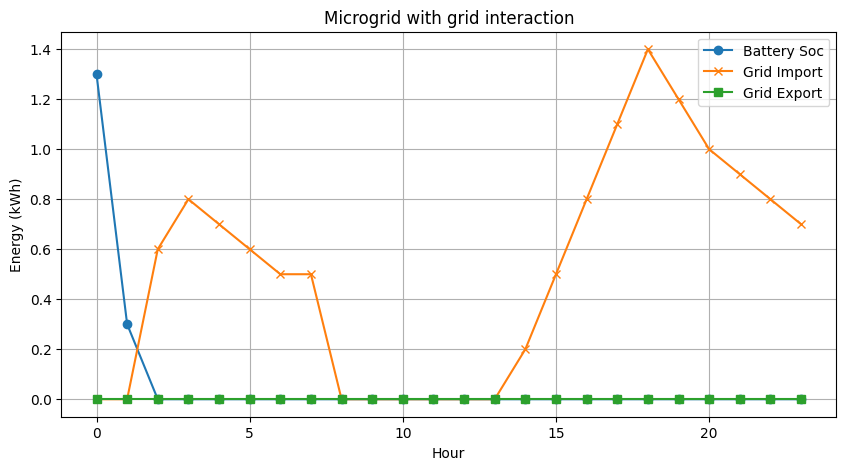

In [16]:
# RESET
soc = 2.5
battery_capacity = 5.0

soc_history = []
grid_import = []
grid_export = []

for t in range(24):
  net = solar[t] - load[t]

  imported = 0
  exported = 0
  if net > 0:
     # Charge battery first
     charge = min(net, battery_capacity - soc)
     soc += charge

     # remaining goes to grid
     exported = net - charge
  else:
     # discharge battery first
      discharge = min(abs(net), soc)
      soc -= discharge

     # remaining comes from grid
      imported = abs(net) - discharge

  # Store Values
  soc_history.append(soc)
  grid_import.append(imported)
  grid_export.append(exported)

# PLOTS (moved outside the loop)
plt.figure(figsize=(10,5))

plt.plot(hours, soc_history, label='Battery Soc', marker='o')
plt.plot(hours, grid_import, label='Grid Import', marker='x')
plt.plot(hours, grid_export, label='Grid Export', marker='s')

plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.title("Microgrid with grid interaction")
plt.legend()
plt.grid(True)

plt.show()